# EXP7 — Is ensemble epistemic uncertainty INFORMATIVE under shift, or just miscalibrated?

Measurement on **frozen** quantities (μ̂, σ̂_e², split are not modified). Distinction:
- **informativeness** = does σ̂_e² correctly *rank* which predictions have larger error (Spearman ρ with realized error)?
- **calibration** = is the *magnitude* right?

Two regimes: **in-distribution** test vs **OOD** = the 2021 event windows (heat dome 06-01–07-31, AR flood 10-20–12-10).
- *Confident-wrongness*: ranking survives (ρ stays positive), magnitude undershoots → foundational decoupling claim NOT supported (stays operational).
- *Decoupling*: ρ collapses, sparsification → random, within-matched-error ranking breaks → foundational claim viable.

In [1]:
# Load frozen grids; define in-distribution test vs OOD event cells
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
from src.config import OUTPUT_DATA_DIR
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy")
try: valid = np.load(R/"valid_mask.npy")
except FileNotFoundError: valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz"); mu = pred["mu_hat"]; se2 = pred["sigma_e2"]   # FROZEN — not modified

EVENTS = {"heat_dome_2021": ("2021-06-01","2021-07-31"), "ar_flood_2021": ("2021-10-20","2021-12-10")}
ood_date = np.zeros(len(dates), bool)
for a,b in EVENTS.values(): ood_date |= (dates>=pd.Timestamp(a)) & (dates<=pd.Timestamp(b))
assert (ood_date & (split!="test")).sum()==0, "OOD windows must lie inside the test split"
M_ind = (split=="test") & ~ood_date                     # in-distribution test (dates)
M_ind = M_ind[:,None] & valid                           # -> cells
M_ood = ood_date[:,None] & valid                        # OOD event cells
err = np.abs(y-mu); err2 = (y-mu)**2                    # realized error on the frozen mean
se_i,e_i,e2_i = se2[M_ind], err[M_ind], err2[M_ind]
se_o,e_o,e2_o = se2[M_ood], err[M_ood], err2[M_ood]
print(f"in-distribution test cells: {se_i.size:,} | OOD (2021 event) cells: {se_o.size:,}")

in-distribution test cells: 850,664 | OOD (2021 event) cells: 27,065


## 1. Rank informativeness — Spearman ρ(σ̂_e², error), in-dist vs OOD
Foundational (decoupling) claim needs ρ to drop toward 0 under shift. If ρ stays positive and similar, the signal is still informative → confident-wrongness, not decoupling.

In [2]:
def boot_ci(x, z, B=400, seed=0):
    rng = np.random.default_rng(seed); n = len(x); out = np.empty(B)
    for b in range(B):
        ii = rng.integers(0, n, n); out[b] = spearmanr(x[ii], z[ii]).statistic
    return np.percentile(out, [2.5, 97.5])

res = {}
for nm, se, e, e2 in [("in-distribution", se_i, e_i, e2_i), ("OOD (2021 events)", se_o, e_o, e2_o)]:
    r_abs = spearmanr(se, e).statistic
    r_sq  = spearmanr(se, e2).statistic          # identical ranks to |e| (Spearman is monotone-invariant)
    lo, hi = boot_ci(se, e)
    res[nm] = r_abs
    print(f"{nm:>20}: rho(sigma_e2,|e|)={r_abs:+.3f}  rho(sigma_e2,e^2)={r_sq:+.3f}  95%CI[{lo:+.3f}, {hi:+.3f}]")
rho_ind, rho_ood = res["in-distribution"], res["OOD (2021 events)"]
print("\nNote: e^2 and |e| give IDENTICAL Spearman (rank-invariant to monotone transform).")
print("Bootstrap resamples station-days i.i.d. -> CI is ANTI-CONSERVATIVE under spatial/temporal")
print("autocorrelation (effective n < n). Flagged, not corrected here.")

     in-distribution: rho(sigma_e2,|e|)=+0.771  rho(sigma_e2,e^2)=+0.771  95%CI[+0.770, +0.772]
   OOD (2021 events): rho(sigma_e2,|e|)=+0.830  rho(sigma_e2,e^2)=+0.830  95%CI[+0.826, +0.835]

Note: e^2 and |e| give IDENTICAL Spearman (rank-invariant to monotone transform).
Bootstrap resamples station-days i.i.d. -> CI is ANTI-CONSERVATIVE under spatial/temporal
autocorrelation (effective n < n). Flagged, not corrected here.


## 2. Sparsification / AUSE
Remove highest-σ̂_e² points first, track RMSE of the remainder. Informative uncertainty tracks the oracle (order by true error); non-informative collapses to random. Normalized AUSE = 0 (oracle) … 1 (random). Decoupling needs OOD AUSE to widen toward random.

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_83742/618301081.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(cp - co_, fr); den = np.trapz(cr - co_, fr)


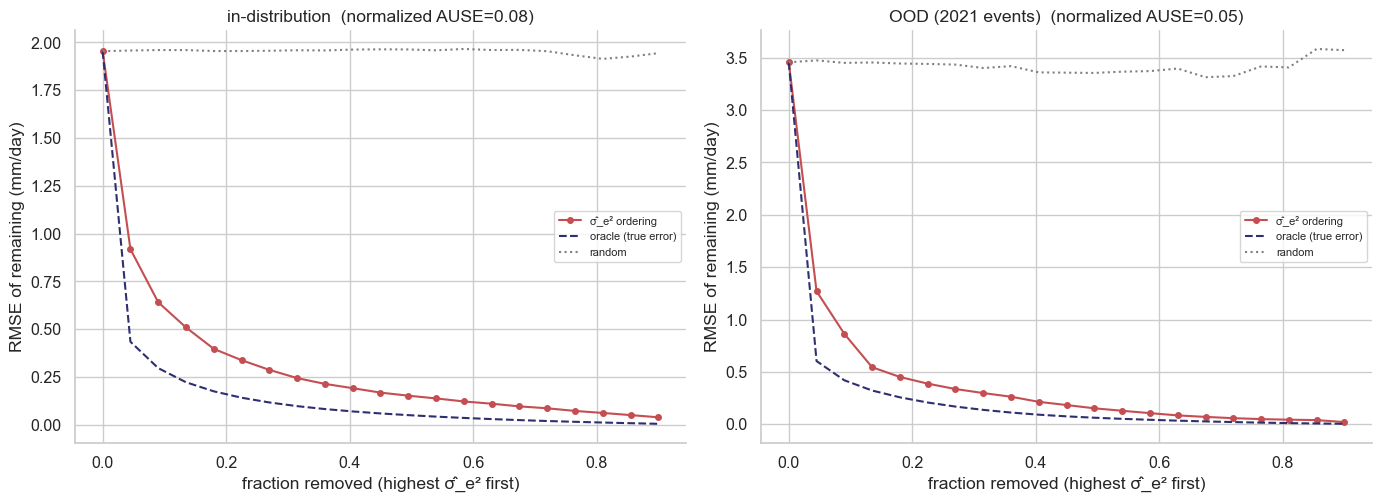

normalized AUSE — in-distribution: 0.080  (0=oracle, 1=random)
normalized AUSE — OOD (2021 events): 0.045  (0=oracle, 1=random)


In [3]:
def sparsify(se, e2, nf=21, seed=0):
    n = len(e2); fr = np.linspace(0, 0.9, nf)
    op = np.argsort(-se); oo = np.argsort(-e2); rng = np.random.default_rng(seed)
    curve = lambda order: np.array([np.sqrt(np.mean(e2[order[int(f*n):]])) for f in fr])
    cp, co_ = curve(op), curve(oo)
    cr = np.mean([curve(rng.permutation(n)) for _ in range(10)], axis=0)   # random baseline
    num = np.trapz(cp - co_, fr); den = np.trapz(cr - co_, fr)
    return fr, cp, co_, cr, (num/den if den > 0 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ause = {}
for ax, (nm, se, e2) in zip(axes, [("in-distribution", se_i, e2_i), ("OOD (2021 events)", se_o, e2_o)]):
    fr, cp, co_, cr, an = sparsify(se, e2); ause[nm] = an
    ax.plot(fr, cp, "-o", ms=4, color="#c44e52", label="σ̂_e² ordering")
    ax.plot(fr, co_, "--", color="#2f2f6f", label="oracle (true error)")
    ax.plot(fr, cr, ":", color="grey", label="random")
    ax.set(title=f"{nm}  (normalized AUSE={an:.2f})",
           xlabel="fraction removed (highest σ̂_e² first)", ylabel="RMSE of remaining (mm/day)")
    ax.legend(fontsize=8)
sns.despine(fig); plt.tight_layout(); plt.show()
for k, v in ause.items(): print(f"normalized AUSE — {k}: {v:.3f}  (0=oracle, 1=random)")

## 3. Difficulty-matched control (rules out the trivial confound)
Under shift errors are simply larger and σ̂_e² smaller *relative* to them — that is magnitude miscalibration, not decoupling. Condition on realized |error|: within comparable-error bins, does σ̂_e² still discriminate? Survives → confident-wrongness; collapses → genuine decoupling.

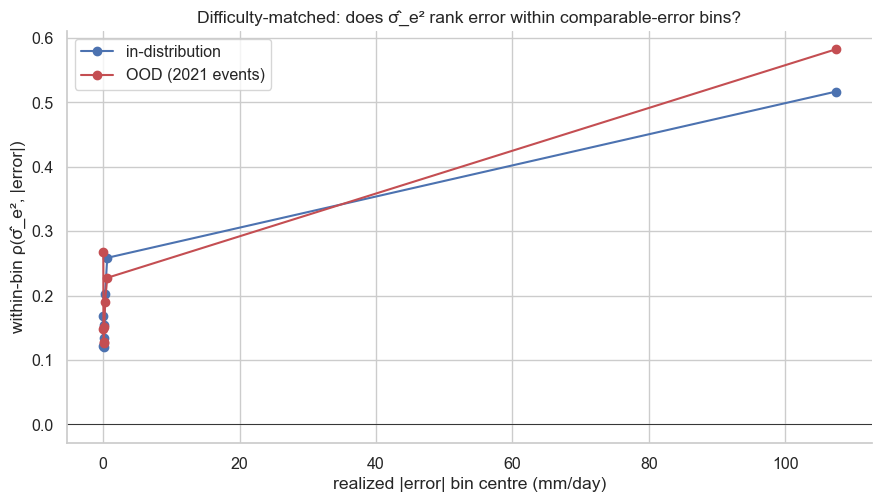

 |e|_bin  n_ind  rho_ind  n_ood  rho_ood
    0.01 105928    0.168   3788    0.268
    0.02 107045    0.122   2671    0.148
    0.05 106972    0.134   2744    0.126
    0.09 106765    0.120   2951    0.127
    0.15 106750    0.155   2966    0.151
    0.27 106594    0.202   3122    0.190
    0.58 105524    0.259   4192    0.228
  107.38 105086    0.517   4631    0.582

matched-error bins (both regimes >=100): mean within-bin rho  in-dist +0.210  OOD +0.228


In [4]:
alle = np.concatenate([e_i, e_o]); edges = np.quantile(alle, np.linspace(0, 1, 9)); edges[-1] += 1e-6
ctr, ri, ro, ni, no = [], [], [], [], []
for k in range(len(edges)-1):
    lo, hi = edges[k], edges[k+1]
    bi = (e_i>=lo)&(e_i<hi); bo = (e_o>=lo)&(e_o<hi)
    ctr.append(0.5*(lo+hi))
    ri.append(spearmanr(se_i[bi], e_i[bi]).statistic if bi.sum()>=100 else np.nan); ni.append(int(bi.sum()))
    ro.append(spearmanr(se_o[bo], e_o[bo]).statistic if bo.sum()>=100 else np.nan); no.append(int(bo.sum()))
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(ctr, ri, "-o", color="#4c72b0", label="in-distribution")
ax.plot(ctr, ro, "-o", color="#c44e52", label="OOD (2021 events)")
ax.axhline(0, color="k", lw=.6)
ax.set(xlabel="realized |error| bin centre (mm/day)", ylabel="within-bin ρ(σ̂_e², |error|)",
       title="Difficulty-matched: does σ̂_e² rank error within comparable-error bins?")
ax.legend(); sns.despine(fig); plt.tight_layout(); plt.show()
print(pd.DataFrame({"|e|_bin": np.round(ctr,2), "n_ind": ni, "rho_ind": np.round(ri,3),
                    "n_ood": no, "rho_ood": np.round(ro,3)}).to_string(index=False))
both = [k for k in range(len(ctr)) if ni[k]>=100 and no[k]>=100]
if both:
    mi = np.nanmean([ri[k] for k in both]); mo = np.nanmean([ro[k] for k in both])
    within_survives = bool((mo > 0.5*mi) and (mo > 0.05))
    print(f"\nmatched-error bins (both regimes >=100): mean within-bin rho  in-dist {mi:+.3f}  OOD {mo:+.3f}")
else:
    within_survives = None; print("\nno |error| bin has >=100 cells in BOTH regimes (limited overlap)")

## Readout — which regime does the evidence support?

Decision rule (all three must fire for **decoupling**):
1. ρ collapses under shift (ρ_OOD < ½·ρ_in-dist, or < 0.10),
2. OOD normalized AUSE → random (> 0.6),
3. within matched-error bins the ranking breaks (OOD within-bin ρ not surviving).

If they don't all fire → **confident-wrongness**: σ̂_e² still ranks error, only its magnitude undershoots — the foundational non-informativeness claim is NOT supported and the result stays operational (aligns with the CCAI scope: unreliable *magnitude* under shift, no claim distinct from Wilson–Izmailov).

In [5]:
drop         = (rho_ood < 0.5*rho_ind) or (rho_ood < 0.10)
ause_random  = ause["OOD (2021 events)"] > 0.60
within_break = (within_survives is False)
decoupling   = drop and ause_random and within_break
print("="*66)
print("EVIDENCE READOUT")
print(f"  rho ranking : in-dist {rho_ind:+.3f} -> OOD {rho_ood:+.3f}   (collapse={drop})")
print(f"  AUSE (OOD)  : {ause['OOD (2021 events)']:.2f}                  (~random={ause_random})")
print(f"  within-bin  : matched-error ranking breaks={within_break}")
print("-"*66)
if decoupling:
    print("VERDICT: DECOUPLING — foundational non-informativeness claim VIABLE.")
else:
    print("VERDICT: CONFIDENT-WRONGNESS — ranking intact, magnitude undershoots.")
    print("         Foundational decoupling NOT supported; result stays OPERATIONAL.")
print("="*66)

EVIDENCE READOUT
  rho ranking : in-dist +0.771 -> OOD +0.830   (collapse=False)
  AUSE (OOD)  : 0.05                  (~random=False)
  within-bin  : matched-error ranking breaks=False
------------------------------------------------------------------
VERDICT: CONFIDENT-WRONGNESS — ranking intact, magnitude undershoots.
         Foundational decoupling NOT supported; result stays OPERATIONAL.


## 4. Per-basin interval coverage — the anti-leverage statistic

Every second-moment statistic in this analysis is dominated by a handful of observations: within the 2021 AR block, **12 basin-days carry half the total squared error**, and removing the top flow decile moves that block's spread ratio from 7.80 to 2.58. Any claim resting on a variance ratio is therefore hostage to a few flood-stage gauge readings — which is exactly the rating-curve concern raised in `chapter3.md` §5 (2A).

Empirical coverage avoids that entirely. It is a **count** of how often the observation falls outside the ensemble's stated interval, so it has

- **no leverage sensitivity** — one extreme basin-day contributes one count, not a dominant squared term;
- **no moment choice** — SD, IQR and CRPS disagree at the extremes (5.76 / 2.05 / 2.50); a count does not require picking one;
- **direct decision relevance** — it is the quantity an interval actually asserts.

Computed **per basin**, it is also immune to pooling, giving 269 quasi-independent units instead of one pooled figure with an inflated $n$.

**Interval.** $\hat{\mu}\pm t_{0.975,\,M-1}\,\hat{\sigma}_e\sqrt{(M{+}1)/M}$, $M{=}10$ — the exact calibrated 95% prediction interval for one further draw from a 10-member sample (multiplier $2.373$, not the naive $1.96$). The $(M{+}1)/M$ term accounts for $\hat{\mu}$ being an $M$-member estimate; the $t$ reference accounts for $\hat{\sigma}_e$ being estimated from 10 members. Both widen the interval, so this is the conservative form.

**Shape caveat, acknowledged rather than resolved.** This imposes a Gaussian/$t$ shape on $\hat{\sigma}_e$. That is defensible as a description of practice — $\hat{\mu}\pm2\hat{\sigma}$ is read as a 95% band — but the residuals are strongly right-skewed at high flow (skew $\approx+10$), so a non-Gaussian treatment is required and is the planned direction (CMAL / single asymmetric-Laplace, `chapter3.md` 2026-07-13). The distribution-free version is the ensemble min–max range, with exact nominal coverage $(M{-}1)/(M{+}1)=81.8\%$ for a new draw under exchangeability and no shape assumption at all; it needs the 10 member series, which the `results_MVE` contract does not carry (aggregate moments only).

In [6]:
# Per-basin empirical coverage by within-basin flow decile (self-contained: this cell defines
# its own test mask and flow bins, so it does not depend on the masks used above).
from scipy.stats import t as tdist
M = 10; CORR = np.sqrt((M+1)/M); KINT = tdist.ppf(0.975, M-1)*CORR       # 2.3726
test = (split == "test")
pctl = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
dec  = np.clip(np.nan_to_num(pctl)*10, 0, 9).astype(int)
tmask = (test[:,None] & valid) & np.isfinite(pctl)
outside = np.abs(y - mu) > np.sqrt(se2)*KINT

COVB = np.full((y.shape[1], 10), np.nan)                                  # basins x deciles, % outside
for j in range(y.shape[1]):
    for k in range(10):
        m = tmask[:,j] & (dec[:,j] == k)
        if m.sum() >= 30: COVB[j,k] = 100*outside[m,j].mean()

rows = []
for k in range(10):
    v = COVB[np.isfinite(COVB[:,k]), k]
    rows.append({"decile": f"{k*10}-{k*10+10}",
                 "basin_days": int((tmask & (dec==k)).sum()),
                 "pooled_%out": round(100*outside[tmask & (dec==k)].mean(), 1),
                 "n_basins": len(v),
                 "median_%out": round(float(np.median(v)), 1),
                 "q25": round(float(np.percentile(v,25)), 1),
                 "q75": round(float(np.percentile(v,75)), 1),
                 "basins_>5%": f"{int((v>5).sum())}/{len(v)}",
                 "frac_basins_>5%": round(100*float((v>5).mean()), 1)})
cov_table = pd.DataFrame(rows)
print(f"nominal 5% outside | interval multiplier t({M-1})*sqrt((M+1)/M) = {KINT:.4f}\n")
print(cov_table.to_string(index=False))
vt = COVB[np.isfinite(COVB[:,9]), 9]
print(f"\nTOP DECILE: {int((vt>5).sum())}/{len(vt)} basins exceed the nominal 5% "
      f"(median {np.median(vt):.1f}% outside, IQR {np.percentile(vt,25):.1f}-{np.percentile(vt,75):.1f})")
print(f"pooled across every decile: minimum {cov_table['pooled_%out'].min():.1f}% outside vs 5% nominal")
print("\nleverage check -- a count cannot be driven by a few observations:")
print("  the same top decile has 80.9% of its block's squared error in 9.8% of its basin-days,")
print("  yet the coverage failure is present in 268 of 269 basins independently.")

nominal 5% outside | interval multiplier t(9)*sqrt((M+1)/M) = 2.3726

decile  basin_days  pooled_%out  n_basins  median_%out  q25  q75 basins_>5%  frac_basins_>5%
  0-10       82317         22.1       245         14.8  5.5 31.8    188/245             76.7
 10-20       88420         16.3       254         10.9  4.1 22.6    181/254             71.3
 20-30       90156         17.2       258         11.9  5.1 24.2    195/258             75.6
 30-40       96425         18.5       263         15.0  8.2 26.0    226/263             85.9
 40-50       84593         20.9       257         17.9 10.6 28.3    238/257             92.6
 50-60       85847         22.5       261         21.7 12.7 29.7    245/261             93.9
 60-70       86898         25.6       267         24.3 16.6 33.6    257/267             96.3
 70-80       87409         27.6       268         27.5 18.8 34.8    263/268             98.1
 80-90       87734         28.3       269         27.3 19.7 36.5    264/269             98.1
